# La struttura della Galassia


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table


In [2]:
gaia = Table.read("data/7e0ddc65-239f-11f1-995e-bc97e148b76b-O-result.vot.gz")

In [3]:
# Posizione(l, b)
l = gaia['l']
b = gaia['b']

# Parallasse
parallax = gaia['parallax']
parallax_err = gaia['parallax_error']

# Velocità Radiale
rv = gaia['radial_velocity']
rv_err = gaia['radial_velocity_error']

# Moto Proprio
pmra = gaia['pmra']
pmdec = gaia['pmdec']

# Considerare solo stelle vicine al piano galattico
mask = (
    (np.abs(b) < 5) &
    (parallax > 0) &
    (parallax_err / parallax < 0.2) &
    (~np.isnan(rv))
)

data = gaia[mask]
# distance is not in parsecs, but in milliarcseconds
distance = 1000 / data['parallax']
data['distance'] = distance

In [15]:
# print column names
print(data.colnames)

['ra', 'dec', 'parallax', 'parallax_error', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity', 'radial_velocity_error', 'l', 'b', 'distance']
     distance     
------------------
2089.4728489479467
48.110836755024415
 752.8068228875383
 1686.222469783083
 806.8636029373129
 2220.958046845352
 3454.436050053875
1316.9752600358609
 1116.265251513472
 649.4538742588586
               ...
1773.5982286182484
 3241.601743796403
  4382.24029133251
 1333.422571049953
1301.2385455085437
  679.056181947107
1406.8030815146542
 1130.557024233518
1393.7221945542547
 2348.995871295535
Length = 100 rows


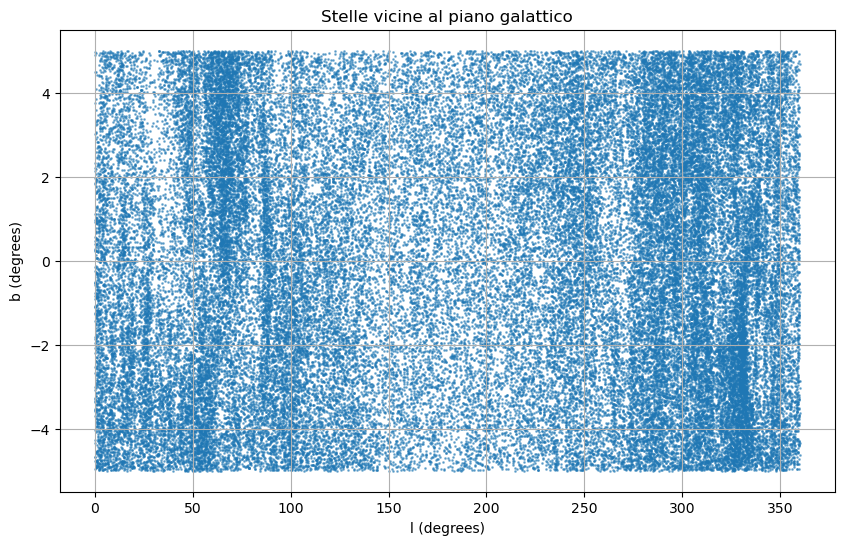

In [5]:
# plot data
plt.figure(figsize=(10, 6))
plt.scatter(data['l'], data['b'], s=1, alpha=0.5)
plt.xlabel('l (degrees)')
plt.ylabel('b (degrees)')
plt.title('Stelle vicine al piano galattico')
plt.grid()
plt.show()

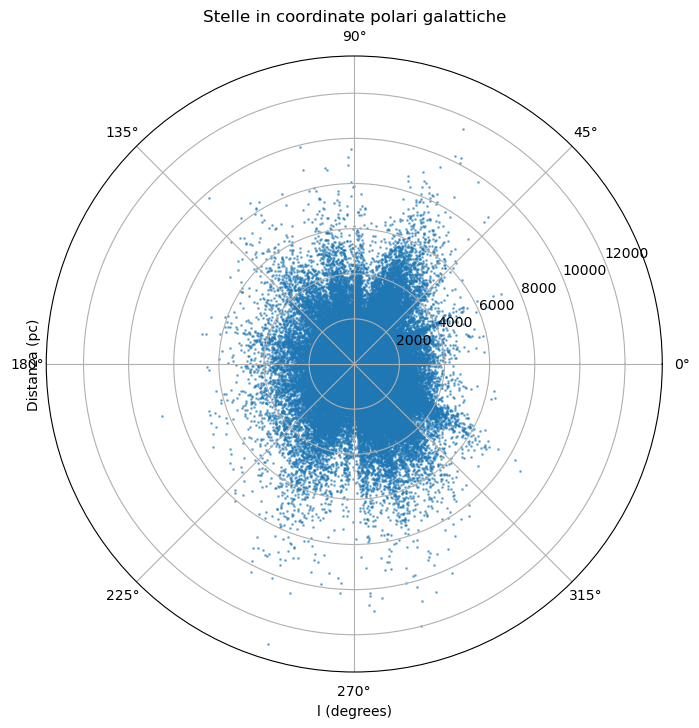

In [26]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')
ax.scatter(np.radians(data['l']), data['distance'], s=1, alpha=0.5)
ax.set_xlabel('l (degrees)')
ax.set_ylabel('Distanza (pc)')
ax.set_title('Stelle in coordinate polari galattiche')
plt.show()

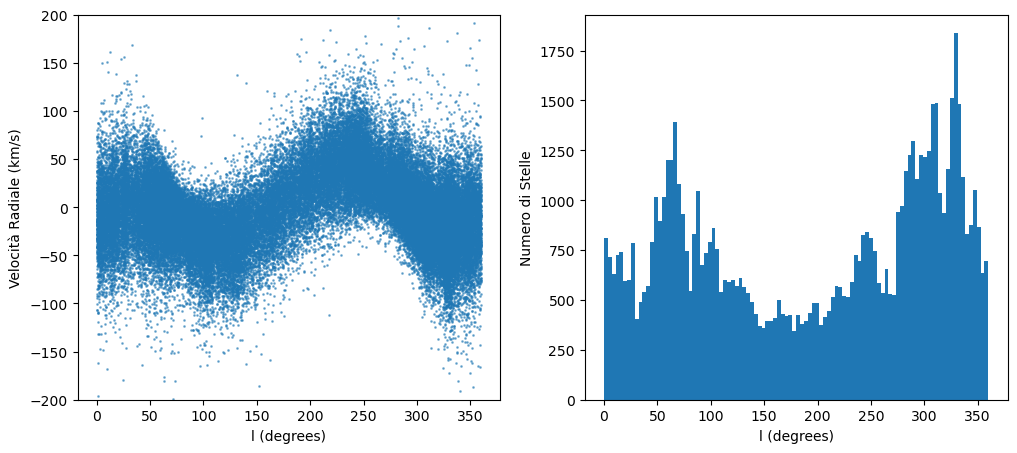

In [7]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
axes[0].scatter(data['l'], data['radial_velocity'], s=1, alpha=0.5, )
axes[0].set_xlabel('l (degrees)')
axes[0].set_ylabel('Velocità Radiale (km/s)')
axes[0].set_ylim(-200, 200)
axes[1].hist(data['l'], bins=100)
axes[1].set_xlabel('l (degrees)')
axes[1].set_ylabel('Numero di Stelle')


plt.show()

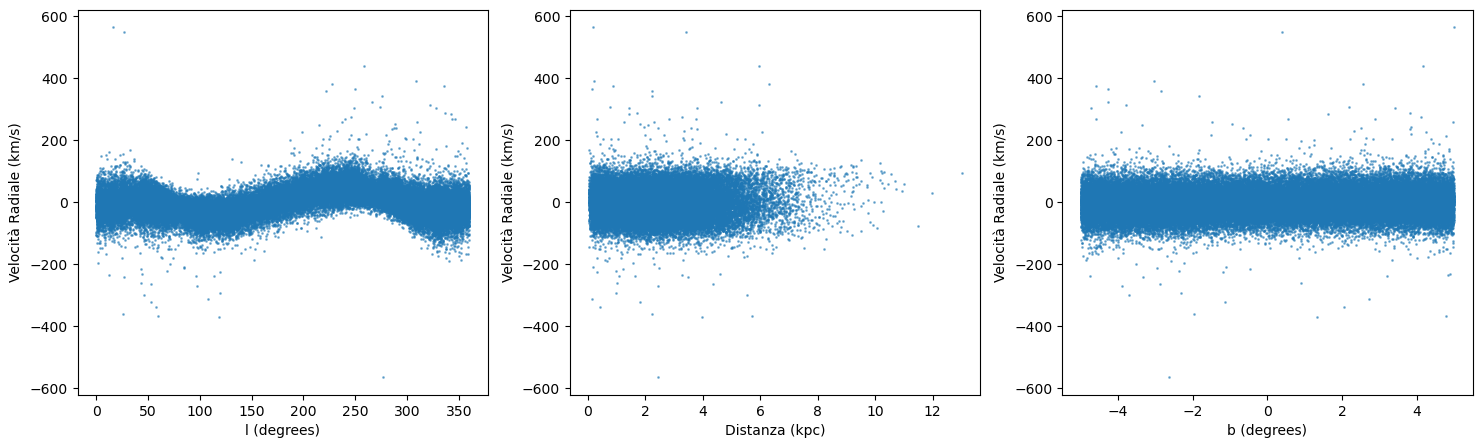

In [8]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 5))
axes[0].scatter(data['l'], data['radial_velocity'], s=1, alpha=0.5)
axes[0].set_xlabel('l (degrees)')
axes[0].set_ylabel('Velocità Radiale (km/s)')
#axes[0].set_ylim(0, 200)
axes[1].scatter(1/data['parallax'], data['radial_velocity'],s=1, alpha=0.5, )
axes[1].set_ylabel('Velocità Radiale (km/s)')
axes[1].set_xlabel('Distanza (kpc)')

axes[2].scatter(data['b'], data['radial_velocity'], s=1, alpha=0.5)
axes[2].set_xlabel('b (degrees)')
axes[2].set_ylabel('Velocità Radiale (km/s)')

plt.show()

In [9]:
import emcee

In [17]:
# likelihood

R_sun = 8200  # kpc

def R_star(d, l):
    return np.sqrt(d**2 + R_sun**2 - 2 * d * R_sun * np.cos(np.radians(l)))

def fun_model(V_rot, l, d, U_sun, V_sun):
    return V_rot * (R_sun/R_star(d, l) - 1) * np.sin(np.radians(l)) - U_sun * np.cos(np.radians(l)) - V_sun * np.sin(np.radians(l))

def log_likelihood(theta, l, b, d, rv, rv_err):
    V_rot, U_sun, V_sun = theta
    model = fun_model(V_rot, l, d, U_sun, V_sun)
    # expect gaussian distribution for the measurements
    sigma2 = rv_err ** 2
    return -0.5 * np.sum((rv - model) ** 2 / sigma2 + np.log(sigma2))


In [18]:
# uninformative priors using uniform distributions

def log_prior(theta):
    V_rot, U_sun, V_sun = theta
    if 0 < V_rot < 300 and -30 < U_sun < 30 and -30 < V_sun < 30: # add U_sun and V_sun priors
        return 0.0
    else:
        return -np.inf

def log_probability(theta, l, b, d, rv, rv_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, l, b, d, rv, rv_err)


In [27]:
from scipy.optimize import least_squares

def residuals(vars, l, d, rv):
    V_rot, U_sun, V_sun = vars
    model = fun_model(V_rot, l, d, U_sun, V_sun)
    return rv - model

result = least_squares(residuals, [220, 0, 0], args=(data['l'], data['distance'], data['radial_velocity']))
V_rot_ls = result.x[0]
U_sun_ls = result.x[1]
V_sun_ls = result.x[2]

print(f"Least-squares estimate: V_rot = {V_rot_ls:.2f} km/s, U_sun = {U_sun_ls:.2f} km/s, V_sun = {V_sun_ls:.2f} km/s")


Least-squares estimate: V_rot = 198.74 km/s, U_sun = 11.74 km/s, V_sun = 21.69 km/s


In [28]:
nwalkers = 32
ndim = 3
initial = np.array([V_rot_ls, U_sun_ls, V_sun_ls])
pos = initial + 5 * np.random.randn(nwalkers, ndim)

print(pos.shape)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim,
    log_probability, 
    args=(data['l'].data, data['b'].data, data['distance'].data, data['radial_velocity'].data, data['radial_velocity_error'].data)
)
sampler.run_mcmc(pos, 5000, progress=True)

(32, 3)


  0%|          | 0/5000 [00:00<?, ?it/s]/home/steve/projects/lab-dati/.conda/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [24:15<00:00,  3.44it/s] 


State([[208.87883018  11.63289046  21.56361918]
 [208.89232408  11.63512569  21.56204901]
 [208.86768548  11.6349225   21.56179891]
 [208.85083418  11.63759396  21.57030614]
 [208.81778117  11.63789882  21.55903881]
 [208.86999094  11.64027016  21.56411508]
 [208.85648349  11.64127524  21.56045086]
 [208.87890896  11.63960169  21.56493152]
 [208.86688923  11.63727194  21.5671558 ]
 [208.87872757  11.63698856  21.56599658]
 [208.90979292  11.63118051  21.56706191]
 [208.89814475  11.63259916  21.56509013]
 [208.85624562  11.63547398  21.55986922]
 [208.8577598   11.63422645  21.56127971]
 [208.86431752  11.64199446  21.56271257]
 [208.86895215  11.64163675  21.56165066]
 [208.9005978   11.63441105  21.56497185]
 [208.87723995  11.64190093  21.56297296]
 [208.86635859  11.63869355  21.56251401]
 [208.89870859  11.63396495  21.56304473]
 [208.87417328  11.63668681  21.56277522]
 [208.88211007  11.64036134  21.56511009]
 [208.8852458   11.63621278  21.56525852]
 [208.82974496  11.64130705 

In [29]:
samples = sampler.get_chain()
print(f"MCMC shape: {samples.shape}")  # (steps, walkers, ndim)

MCMC shape: (5000, 32, 3)


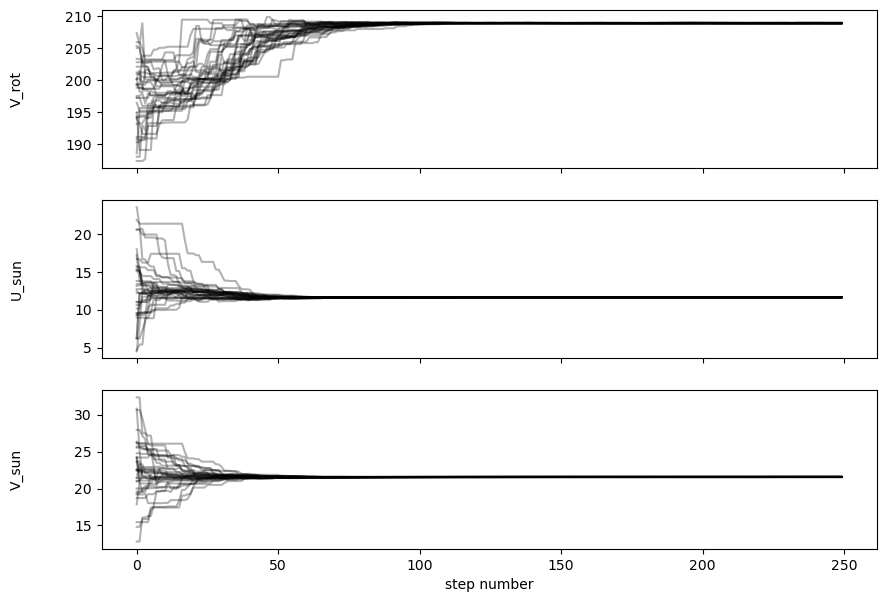

In [32]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
labels = ["V_rot", "U_sun", "V_sun"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i][:250], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

Autocorrelation time: 43.36
Flattened samples shape: (10432, 3)


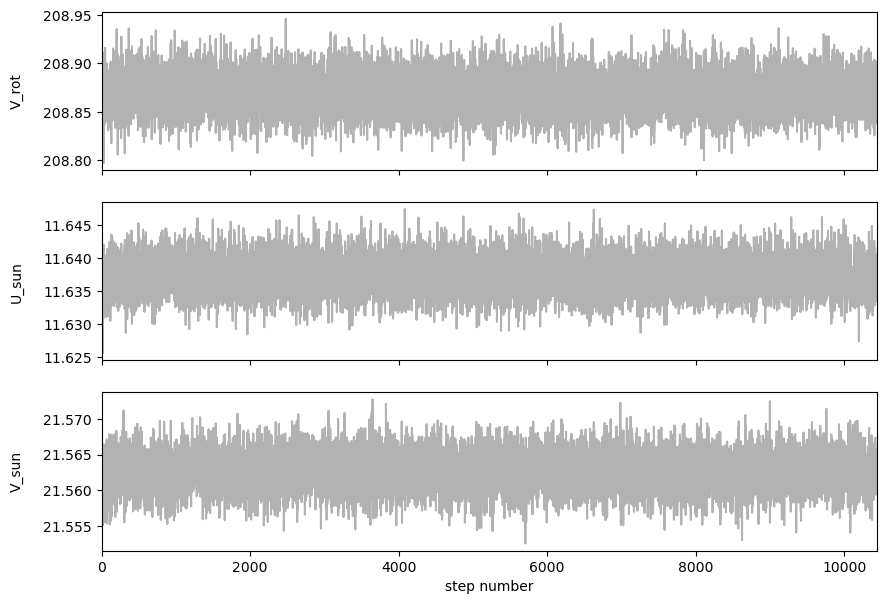

In [33]:
# Check autocorrelation time and convergence
tau = sampler.get_autocorr_time()
print(f"Autocorrelation time: {tau[0]:.2f}")

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(f"Flattened samples shape: {flat_samples.shape}")

# plot flat samples
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(flat_samples[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(flat_samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("step number");

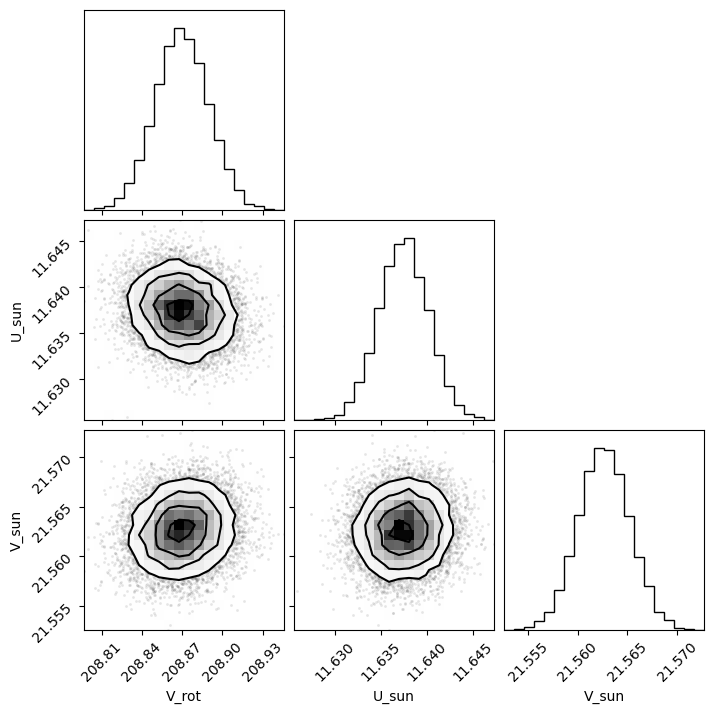

In [34]:
import corner

fig = corner.corner(
    flat_samples, labels=labels, truths=[220, 10, 10]
)
plt.show()

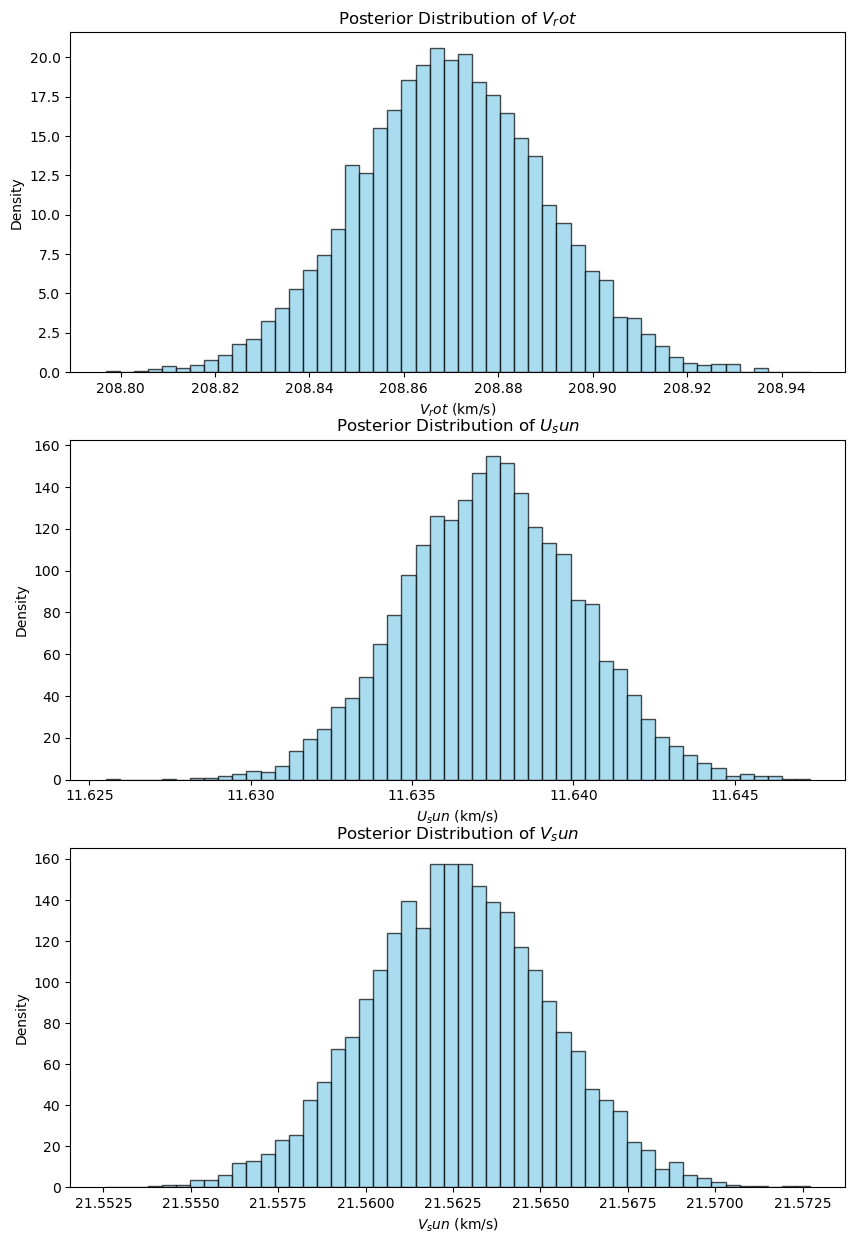

In [37]:
# posterior distribution
fig, ax = plt.subplots(3, figsize=(10, 15))
for i in range(3):
    ax[i].hist(flat_samples[:, i], bins=50, density=True, alpha=0.7, edgecolor='black', color='skyblue')
    #ax[i].axvline(result.x[i], color='orange', linestyle='--', linewidth=2, label=f'LS estimate: {result.x[i]:.2f} km/s')
    ax[i].set_xlabel(f"${{{labels[i]}}}$ (km/s)")
    ax[i].set_ylabel("Density")
    ax[i].set_title(f"Posterior Distribution of ${{{labels[i]}}}$")
#ax.legend()
plt.show()

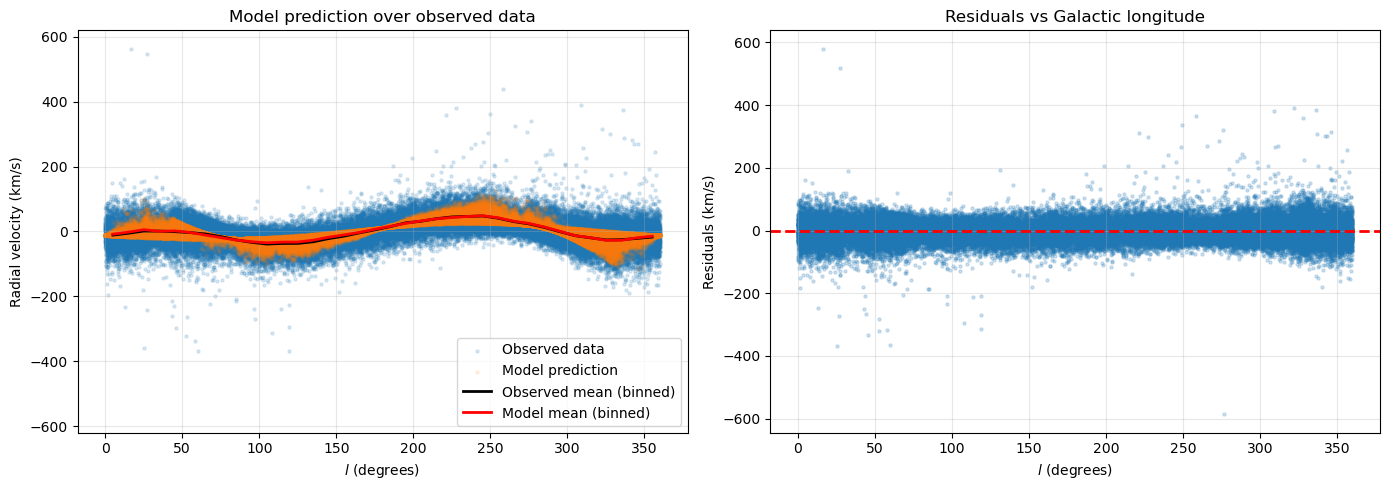

In [40]:
# Use posterior median parameters when available; otherwise fallback to least-squares
if 'flat_samples' in globals() and len(flat_samples) > 0:
    theta_hat = np.median(flat_samples, axis=0)
else:
    theta_hat = result.x

V_rot_hat, U_sun_hat, V_sun_hat = theta_hat

# Predict radial velocity for each star using its own distance
l_obs = np.asarray(data['l'].data)
d_obs = np.asarray(data['distance'].data)
rv_obs = np.asarray(data['radial_velocity'].data)
rv_pred = fun_model(V_rot_hat, l_obs, d_obs, U_sun_hat, V_sun_hat)

# Build binned trends vs Galactic longitude for a clearer overlay
bins = np.linspace(0, 360, 37)  # 10-degree bins
centers = 0.5 * (bins[:-1] + bins[1:])
obs_binned = np.full(len(centers), np.nan)
pred_binned = np.full(len(centers), np.nan)

for i in range(len(centers)):
    in_bin = (l_obs >= bins[i]) & (l_obs < bins[i + 1])
    if np.any(in_bin):
        obs_binned[i] = np.mean(rv_obs[in_bin])
        pred_binned[i] = np.mean(rv_pred[in_bin])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data + model overlay
ax = axes[0]
ax.scatter(l_obs, rv_obs, s=5, alpha=0.15, label='Observed data')
ax.scatter(l_obs, rv_pred, s=5, alpha=0.10, label='Model prediction')
ax.plot(centers, obs_binned, 'k-', linewidth=2, label='Observed mean (binned)')
ax.plot(centers, pred_binned, 'r-', linewidth=2, label='Model mean (binned)')
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Radial velocity (km/s)')
ax.set_title('Model prediction over observed data')
ax.grid(alpha=0.3)
ax.legend()

# Residuals
ax = axes[1]
residuals = rv_obs - rv_pred
ax.scatter(l_obs, residuals, s=5, alpha=0.2)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Residuals (km/s)')
ax.set_title('Residuals vs Galactic longitude')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()